# CSQA Layer-Output And Internal-State Noising Analysis

Intervention notebook for a single model family and a single task.

- model family: Qwen2.5
- target checkpoint: 3B instruct model
- intervention class: additive noise on internal states
- decision space: constrained A-E answer-choice logits only


In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

from src.data.load_csqa import load_csqa

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)


/home/ubuntu/Transformer-Decision-Traces/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Default EVAL_LIMIT keeps the multi-section intervention scan tractable. None uses the full validation split.


In [2]:
MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
EVAL_SPLIT = "validation"
EVAL_LIMIT = 256
MAX_SEQ_LEN = 384
CLEAN_BATCH_SIZE = 4
INTERVENTION_BATCH_SIZE = 2
MAIN_NOISE_SCALE = 0.25
DOSE_RESPONSE_SCALES = [0.05, 0.10, 0.25, 0.50]
SEED_ROBUSTNESS_SEEDS = [42, 43, 44, 45]
SEED = 42
USE_BFLOAT16_IF_AVAILABLE = True


## Data And Model Setup


In [3]:
torch.manual_seed(SEED)
np.random.seed(SEED)

LETTERS = ["A", "B", "C", "D", "E"]

eval_rows = load_csqa(split=EVAL_SPLIT, limit=EVAL_LIMIT).copy()
eval_rows["n_choices"] = eval_rows["csqa_choices"].map(len)
eval_rows["prompt_len_chars"] = eval_rows["text"].str.len()
assert eval_rows["n_choices"].eq(5).all(), "Expected 5 choices for every CSQA row."

if torch.cuda.is_available():
    if USE_BFLOAT16_IF_AVAILABLE and torch.cuda.is_bf16_supported():
        model_dtype = torch.bfloat16
    else:
        model_dtype = torch.float16
    device_map = "auto"
else:
    model_dtype = torch.float32
    device_map = None

tok = AutoTokenizer.from_pretrained(MODEL_ID)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
tok.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=model_dtype,
    device_map=device_map,
    attn_implementation="eager",
)
model.eval()


def build_answer_token_ids(tok):
    out = {}
    for letter in LETTERS:
        ids = tok(" " + letter, add_special_tokens=False)["input_ids"]
        if len(ids) != 1:
            raise ValueError(f"Answer token '{letter}' is not single-token: {ids}")
        out[letter] = int(ids[0])
    return out


answer_token_ids = build_answer_token_ids(tok)
answer_ids = [answer_token_ids[l] for l in LETTERS]
answer_id_tensor = torch.tensor(answer_ids, dtype=torch.long)

display(eval_rows[["example_id", "answerKey", "prompt_len_chars"]].head())
print("eval rows:", len(eval_rows))
print("answer token ids:", answer_token_ids)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 434/434 [00:46<00:00,  9.33it/s]


,example_id,answerKey,prompt_len_chars
0,701fac8b8c04ab56c4394b2e7b2aa8df,A,187
1,1db37ef1b4ebdcbc12a7d7dec87472a8,A,145
2,a5cb28d53c4cd35c06fbbbb3dbf6aaa8,B,149
3,ce6c00c4f3edcd54ab4fa1e3a8582e7c,A,141
4,054aade2878f1bd189aa590565583d91,A,158


eval rows: 256
answer token ids: {'A': 362, 'B': 425, 'C': 356, 'D': 422, 'E': 468}


## Helper Functions


In [4]:
def get_final_norm_module(model):
    candidates = [
        "model.norm",
        "model.final_layernorm",
        "transformer.ln_f",
        "gpt_neox.final_layer_norm",
    ]
    for path in candidates:
        cur = model
        ok = True
        for part in path.split("."):
            if not hasattr(cur, part):
                ok = False
                break
            cur = getattr(cur, part)
        if ok:
            return cur
    return None


def get_decoder_layers(model):
    candidates = [
        "model.layers",
        "transformer.h",
        "gpt_neox.layers",
    ]
    for path in candidates:
        cur = model
        ok = True
        for part in path.split("."):
            if not hasattr(cur, part):
                ok = False
                break
            cur = getattr(cur, part)
        if ok:
            return cur
    raise ValueError("Could not locate decoder layers on this model.")


def encode_prompts(texts, tok, max_seq_len):
    batch = tok(
        list(texts),
        add_special_tokens=False,
        truncation=True,
        max_length=max_seq_len,
        padding=True,
        return_tensors="pt",
    )
    pos = []
    for mask in batch["attention_mask"]:
        nz = torch.nonzero(mask, as_tuple=False).view(-1)
        pos.append(int(nz[-1].item()))
    batch["decision_pos"] = torch.tensor(pos, dtype=torch.long)
    return batch


def compute_choice_metrics(choice_logits, true_choice_idx):
    pred_idx = choice_logits.argmax(dim=-1)
    row_idx = torch.arange(choice_logits.shape[0], device=choice_logits.device)
    true_logits = choice_logits[row_idx, true_choice_idx]
    other_logits = choice_logits.clone()
    other_logits[row_idx, true_choice_idx] = -torch.inf
    best_other = other_logits.max(dim=-1).values
    correct_margin = true_logits - best_other
    return pred_idx.detach().cpu(), correct_margin.detach().cpu()


def apply_token_noise(hidden, decision_pos, noise_scale):
    row_idx = torch.arange(hidden.shape[0], device=hidden.device)
    token_hidden = hidden[row_idx, decision_pos]
    rms = token_hidden.float().pow(2).mean(dim=-1, keepdim=True).sqrt().to(token_hidden.dtype)
    noise = torch.randn_like(token_hidden) * (noise_scale * rms)
    hidden_out = hidden.clone()
    hidden_out[row_idx, decision_pos] = token_hidden + noise
    return hidden_out


def intervention_summary(df, group_cols):
    summary_all = (
        df.groupby(group_cols)
        .agg(
            mean_correct_margin_delta=("correct_margin_delta", "mean"),
            prediction_preservation_rate=("prediction_preserved", "mean"),
            noised_accuracy=("noised_is_correct", "mean"),
        )
    )

    summary_clean_correct = (
        df.loc[df["clean_is_correct"]]
        .groupby(group_cols)
        .agg(
            clean_correct_break_rate=("clean_correct_broken", "mean"),
            noised_accuracy_on_clean_correct=("noised_is_correct", "mean"),
        )
    )

    return summary_all.join(summary_clean_correct, how="left").reset_index()


def standardize_series(values):
    values = np.asarray(values, dtype=float)
    mean = float(np.mean(values))
    std = float(np.std(values))
    if std <= 0:
        return np.zeros_like(values, dtype=float)
    return (values - mean) / std


decoder_layers = get_decoder_layers(model)
final_norm = get_final_norm_module(model)
L = len(decoder_layers)
answer_ids_on_device = answer_id_tensor.to(model.lm_head.weight.device)
log_answer_choice_count = float(np.log(len(LETTERS)))

substep_display_names = {
    "pre_attn": "Pre-attention residual state",
    "post_attn": "Post-attention residual state",
    "post_mlp": "Post-feed-forward residual state",
}

component_display_names = {
    "attention_output": "Attention output",
    "feed_forward_output": "Feed-forward output",
}

probe_cpu = encode_prompts(eval_rows["text"].head(1), tok, MAX_SEQ_LEN)
probe_pos = int(probe_cpu["decision_pos"][0].item())
probe = {k: v.to(model.device) for k, v in probe_cpu.items() if k != "decision_pos"}
with torch.no_grad():
    probe_out = model(**probe, output_hidden_states=True, return_dict=True, use_cache=False)

hidden_probe = probe_out.hidden_states
L_plus_1 = len(hidden_probe)
raw_last = hidden_probe[-1][0, probe_pos].float()
target_choice_logits = probe_out.logits[0, probe_pos, answer_ids_on_device].float().detach().cpu()
raw_choice_logits = torch.mv(model.lm_head.weight[answer_ids_on_device].float().detach().cpu(), raw_last.detach().cpu())

if final_norm is not None:
    normed_last = final_norm(raw_last.unsqueeze(0)).squeeze(0)
    normed_choice_logits = torch.mv(model.lm_head.weight[answer_ids_on_device].float().detach().cpu(), normed_last.detach().cpu())
    raw_err = torch.mean(torch.abs(raw_choice_logits - target_choice_logits)).item()
    normed_err = torch.mean(torch.abs(normed_choice_logits - target_choice_logits)).item()
    LAST_LAYER_NEEDS_NORM = bool(normed_err < raw_err)
else:
    LAST_LAYER_NEEDS_NORM = False


def maybe_apply_final_norm_gpu(h, layer_idx):
    if final_norm is None:
        return h
    if layer_idx < L:
        return final_norm(h)
    if LAST_LAYER_NEEDS_NORM:
        return final_norm(h)
    return h


print("decoder layers:", L)


decoder layers: 36


## Clean Baseline

Final answer-choice outputs without intervention.


In [5]:
def extract_clean_baseline(frame):
    rows = []

    for start in tqdm(range(0, len(frame), CLEAN_BATCH_SIZE), total=int(math.ceil(len(frame) / CLEAN_BATCH_SIZE)), desc="clean baseline"):
        batch_df = frame.iloc[start:start + CLEAN_BATCH_SIZE].reset_index(drop=True)
        batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
        decision_pos = batch_cpu.pop("decision_pos")
        batch = {k: v.to(model.device) for k, v in batch_cpu.items()}
        decision_pos = decision_pos.to(model.device)
        true_choice_idx = torch.tensor([LETTERS.index(str(x)) for x in batch_df["answerKey"].tolist()], dtype=torch.long, device=model.device)

        with torch.no_grad():
            out = model(**batch, return_dict=True, use_cache=False)

        row_idx = torch.arange(len(batch_df), device=decision_pos.device)
        final_logits = out.logits[row_idx, decision_pos][:, answer_ids_on_device].float()
        pred_idx, correct_margin = compute_choice_metrics(final_logits, true_choice_idx)
        clean_is_correct = pred_idx.eq(true_choice_idx.detach().cpu())

        for bi in range(len(batch_df)):
            rows.append(
                {
                    "example_id": batch_df.loc[bi, "example_id"],
                    "true_choice_idx": int(true_choice_idx[bi].item()),
                    "clean_prediction_idx": int(pred_idx[bi].item()),
                    "clean_prediction": LETTERS[int(pred_idx[bi].item())],
                    "clean_correct_margin": float(correct_margin[bi].item()),
                    "clean_is_correct": bool(clean_is_correct[bi].item()),
                }
            )

    return pd.DataFrame(rows)


clean_df = extract_clean_baseline(eval_rows)
analysis_df = eval_rows.merge(clean_df, on="example_id", how="left", validate="one_to_one")

display(
    analysis_df[["example_id", "answerKey", "clean_prediction", "clean_correct_margin", "clean_is_correct"]].head()
)
print("clean accuracy:", round(float(analysis_df["clean_is_correct"].mean()), 4))


clean baseline: 100%|██████████| 64/64 [00:03<00:00, 20.94it/s]


,example_id,answerKey,clean_prediction,clean_correct_margin,clean_is_correct
0,701fac8b8c04ab56c4394b2e7b2aa8df,A,D,-1.500,False
1,1db37ef1b4ebdcbc12a7d7dec87472a8,A,A,9.625,True
2,a5cb28d53c4cd35c06fbbbb3dbf6aaa8,B,B,10.625,True
3,ce6c00c4f3edcd54ab4fa1e3a8582e7c,A,A,14.000,True
4,054aade2878f1bd189aa590565583d91,A,D,-8.125,False


clean accuracy: 0.8086


## Layer-Output Noising

Noise is injected at the output of one decoder layer at a time. Only the decision-position token is modified.


In [6]:
def run_layer_output_noising_scan(frame, noise_scale, desc):
    rows = []

    for target_layer in tqdm(range(L), total=L, desc=desc):
        torch.manual_seed(SEED + target_layer)
        current_state = {}

        def noise_hook(module, args, output):
            hidden = output[0] if isinstance(output, tuple) else output
            hidden_out = apply_token_noise(hidden, current_state["decision_pos"], noise_scale)
            if isinstance(output, tuple):
                return (hidden_out,) + output[1:]
            return hidden_out

        handle = decoder_layers[target_layer].register_forward_hook(noise_hook)

        try:
            for start in range(0, len(frame), INTERVENTION_BATCH_SIZE):
                batch_df = frame.iloc[start:start + INTERVENTION_BATCH_SIZE].reset_index(drop=True)
                batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
                decision_pos = batch_cpu.pop("decision_pos")
                batch = {k: v.to(model.device) for k, v in batch_cpu.items()}
                decision_pos = decision_pos.to(model.device)
                true_choice_idx = torch.tensor([LETTERS.index(str(x)) for x in batch_df["answerKey"].tolist()], dtype=torch.long, device=model.device)

                current_state["decision_pos"] = decision_pos

                with torch.no_grad():
                    out = model(**batch, return_dict=True, use_cache=False)

                row_idx = torch.arange(len(batch_df), device=decision_pos.device)
                final_logits = out.logits[row_idx, decision_pos][:, answer_ids_on_device].float()
                pred_idx, correct_margin = compute_choice_metrics(final_logits, true_choice_idx)
                noised_is_correct = pred_idx.eq(true_choice_idx.detach().cpu())

                for bi in range(len(batch_df)):
                    rows.append(
                        {
                            "example_id": batch_df.loc[bi, "example_id"],
                            "target_layer": int(target_layer),
                            "noise_scale": float(noise_scale),
                            "noised_prediction_idx": int(pred_idx[bi].item()),
                            "noised_prediction": LETTERS[int(pred_idx[bi].item())],
                            "noised_correct_margin": float(correct_margin[bi].item()),
                            "noised_is_correct": bool(noised_is_correct[bi].item()),
                        }
                    )
        finally:
            handle.remove()

    return pd.DataFrame(rows)


layer_output_df = run_layer_output_noising_scan(eval_rows, MAIN_NOISE_SCALE, "layer-output noising")
layer_output_df = layer_output_df.merge(
    analysis_df[["example_id", "clean_prediction_idx", "clean_correct_margin", "clean_is_correct"]],
    on="example_id",
    how="left",
    validate="many_to_one",
)
layer_output_df["prediction_preserved"] = layer_output_df["noised_prediction_idx"].eq(layer_output_df["clean_prediction_idx"])
layer_output_df["correct_margin_delta"] = layer_output_df["noised_correct_margin"] - layer_output_df["clean_correct_margin"]
layer_output_df["clean_correct_broken"] = layer_output_df["clean_is_correct"] & (~layer_output_df["noised_is_correct"])

layer_output_summary = intervention_summary(layer_output_df, ["target_layer"])
layer_output_summary["layer_index_1based"] = layer_output_summary["target_layer"] + 1

display(layer_output_summary.round(4))


layer-output noising: 100%|██████████| 36/36 [03:02<00:00,  5.07s/it]


,target_layer,mean_correct_margin_delta,prediction_preservation_rate,noised_accuracy,clean_correct_break_rate,noised_accuracy_on_clean_correct,layer_index_1based
0,0,-0.1860,0.9492,0.8008,0.0290,0.9710,1
1,1,-0.0518,0.9570,0.8047,0.0193,0.9807,2
2,2,-0.0337,0.9648,0.8164,0.0097,0.9903,3
3,3,-0.0601,0.9609,0.8125,0.0145,0.9855,4
4,4,0.0830,0.9570,0.8047,0.0242,0.9758,5
5,5,-0.0581,0.9648,0.8125,0.0097,0.9903,6
6,6,0.0396,0.9570,0.8086,0.0145,0.9855,7
7,7,-0.0347,0.9648,0.7969,0.0242,0.9758,8
8,8,0.0962,0.9727,0.8203,0.0048,0.9952,9
9,9,0.1157,0.9727,0.8047,0.0145,0.9855,10


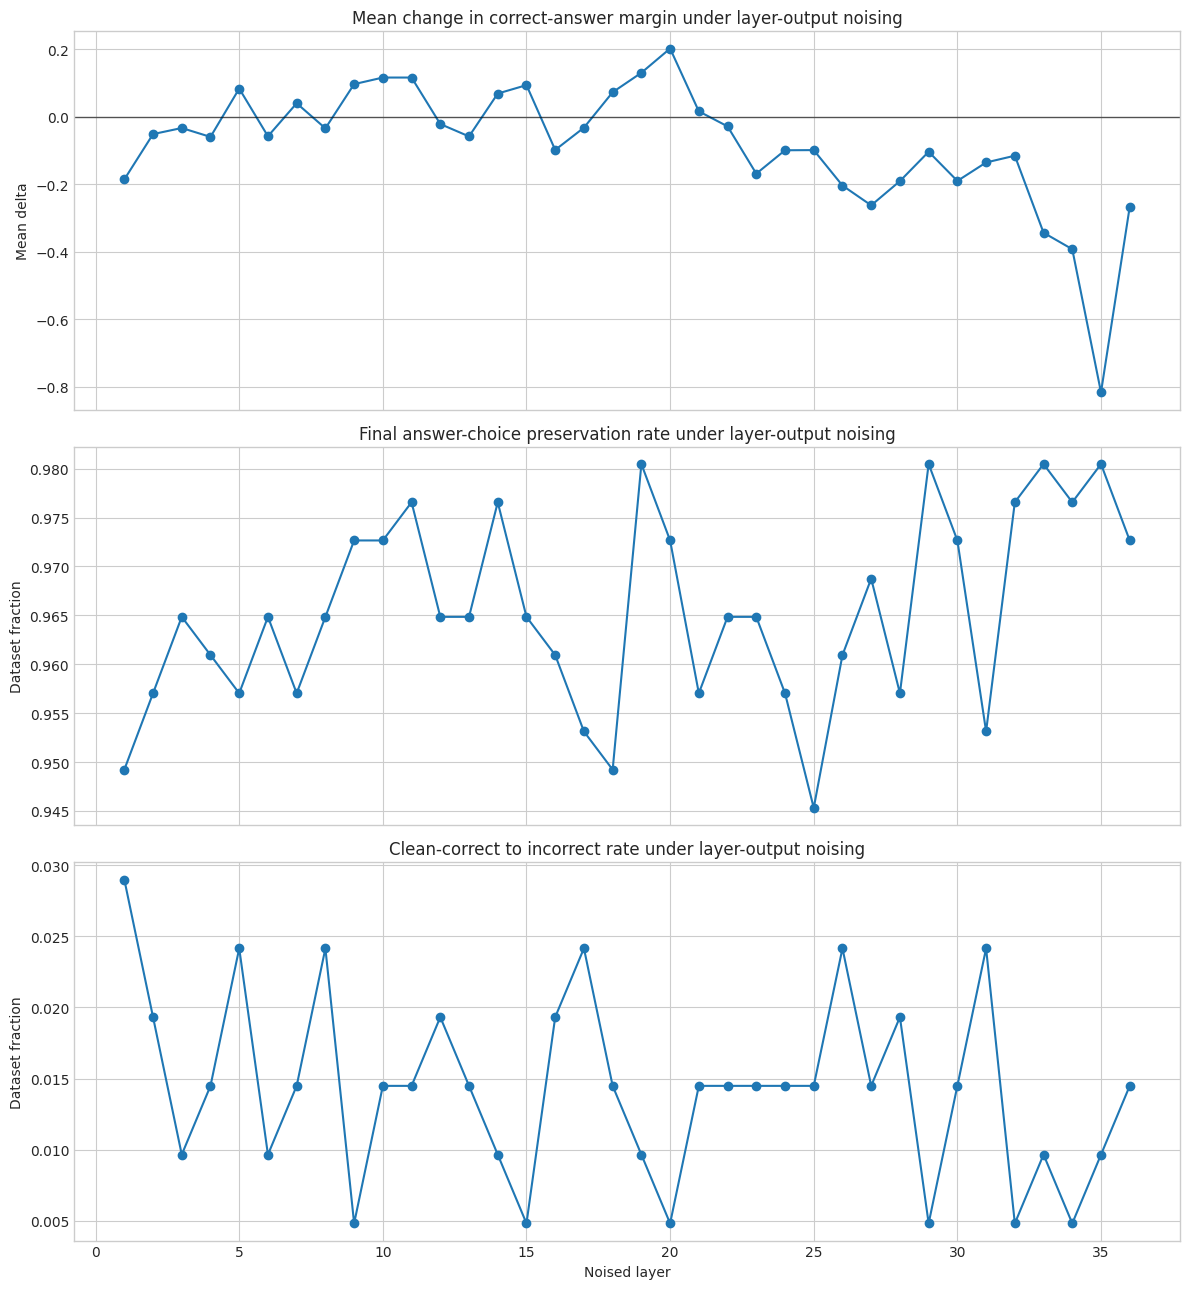

In [7]:
layers_1based = layer_output_summary["layer_index_1based"].to_numpy()

fig, axes = plt.subplots(3, 1, figsize=(12, 13), sharex=True)

axes[0].plot(layers_1based, layer_output_summary["mean_correct_margin_delta"], marker="o")
axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[0].set_ylabel("Mean delta")
axes[0].set_title("Mean change in correct-answer margin under layer-output noising")

axes[1].plot(layers_1based, layer_output_summary["prediction_preservation_rate"], marker="o")
axes[1].set_ylabel("Dataset fraction")
axes[1].set_title("Final answer-choice preservation rate under layer-output noising")

axes[2].plot(layers_1based, layer_output_summary["clean_correct_break_rate"], marker="o")
axes[2].set_xlabel("Noised layer")
axes[2].set_ylabel("Dataset fraction")
axes[2].set_title("Clean-correct to incorrect rate under layer-output noising")

plt.tight_layout()
plt.show()


In [8]:
display(
    layer_output_summary.sort_values(
        ["clean_correct_break_rate", "mean_correct_margin_delta"],
        ascending=[False, True],
    )[[
        "layer_index_1based",
        "mean_correct_margin_delta",
        "prediction_preservation_rate",
        "noised_accuracy",
        "clean_correct_break_rate",
        "noised_accuracy_on_clean_correct",
    ]]
    .head(10)
    .round(4)
)


,layer_index_1based,mean_correct_margin_delta,prediction_preservation_rate,noised_accuracy,clean_correct_break_rate,noised_accuracy_on_clean_correct
0,1,-0.1860,0.9492,0.8008,0.0290,0.9710
25,26,-0.2041,0.9609,0.7969,0.0242,0.9758
30,31,-0.1357,0.9531,0.8086,0.0242,0.9758
7,8,-0.0347,0.9648,0.7969,0.0242,0.9758
16,17,-0.0327,0.9531,0.8008,0.0242,0.9758
4,5,0.0830,0.9570,0.8047,0.0242,0.9758
27,28,-0.1909,0.9570,0.8086,0.0193,0.9807
15,16,-0.0986,0.9609,0.7969,0.0193,0.9807
1,2,-0.0518,0.9570,0.8047,0.0193,0.9807
11,12,-0.0220,0.9648,0.7969,0.0193,0.9807


## Substep Noising

Noise is injected at one internal residual-state checkpoint at a time.

- pre-attention residual state
- post-attention residual state
- post-feed-forward residual state


In [9]:
def run_substep_noising_scan(frame, noise_scale):
    rows = []

    for target_layer in tqdm(range(L), total=L, desc="substep noising"):
        for substep_idx, target_substep in enumerate(["pre_attn", "post_attn", "post_mlp"]):
            torch.manual_seed(SEED + 1000 * (target_layer + 1) + substep_idx)
            current_state = {}

            if target_substep == "pre_attn":
                def hook_fn(module, args):
                    hidden = args[0]
                    hidden_out = apply_token_noise(hidden, current_state["decision_pos"], noise_scale)
                    return (hidden_out,) + args[1:]

                handle = decoder_layers[target_layer].register_forward_pre_hook(hook_fn)

            elif target_substep == "post_attn":
                def hook_fn(module, args):
                    hidden = args[0]
                    hidden_out = apply_token_noise(hidden, current_state["decision_pos"], noise_scale)
                    return (hidden_out,) + args[1:]

                if not hasattr(decoder_layers[target_layer], "post_attention_layernorm"):
                    raise ValueError("Expected post_attention_layernorm on decoder layer.")
                handle = decoder_layers[target_layer].post_attention_layernorm.register_forward_pre_hook(hook_fn)

            else:
                def hook_fn(module, args, output):
                    hidden = output[0] if isinstance(output, tuple) else output
                    hidden_out = apply_token_noise(hidden, current_state["decision_pos"], noise_scale)
                    if isinstance(output, tuple):
                        return (hidden_out,) + output[1:]
                    return hidden_out

                handle = decoder_layers[target_layer].register_forward_hook(hook_fn)

            try:
                for start in range(0, len(frame), INTERVENTION_BATCH_SIZE):
                    batch_df = frame.iloc[start:start + INTERVENTION_BATCH_SIZE].reset_index(drop=True)
                    batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
                    decision_pos = batch_cpu.pop("decision_pos")
                    batch = {k: v.to(model.device) for k, v in batch_cpu.items()}
                    decision_pos = decision_pos.to(model.device)
                    true_choice_idx = torch.tensor([LETTERS.index(str(x)) for x in batch_df["answerKey"].tolist()], dtype=torch.long, device=model.device)

                    current_state["decision_pos"] = decision_pos

                    with torch.no_grad():
                        out = model(**batch, return_dict=True, use_cache=False)

                    row_idx = torch.arange(len(batch_df), device=decision_pos.device)
                    final_logits = out.logits[row_idx, decision_pos][:, answer_ids_on_device].float()
                    pred_idx, correct_margin = compute_choice_metrics(final_logits, true_choice_idx)
                    noised_is_correct = pred_idx.eq(true_choice_idx.detach().cpu())

                    for bi in range(len(batch_df)):
                        rows.append(
                            {
                                "example_id": batch_df.loc[bi, "example_id"],
                                "target_layer": int(target_layer),
                                "target_substep": target_substep,
                                "noise_scale": float(noise_scale),
                                "noised_prediction_idx": int(pred_idx[bi].item()),
                                "noised_prediction": LETTERS[int(pred_idx[bi].item())],
                                "noised_correct_margin": float(correct_margin[bi].item()),
                                "noised_is_correct": bool(noised_is_correct[bi].item()),
                            }
                        )
            finally:
                handle.remove()

    return pd.DataFrame(rows)


substep_df = run_substep_noising_scan(eval_rows, MAIN_NOISE_SCALE)
substep_df = substep_df.merge(
    analysis_df[["example_id", "clean_prediction_idx", "clean_correct_margin", "clean_is_correct"]],
    on="example_id",
    how="left",
    validate="many_to_one",
)
substep_df["prediction_preserved"] = substep_df["noised_prediction_idx"].eq(substep_df["clean_prediction_idx"])
substep_df["correct_margin_delta"] = substep_df["noised_correct_margin"] - substep_df["clean_correct_margin"]
substep_df["clean_correct_broken"] = substep_df["clean_is_correct"] & (~substep_df["noised_is_correct"])

substep_summary = intervention_summary(substep_df, ["target_layer", "target_substep"])
substep_summary["layer_index_1based"] = substep_summary["target_layer"] + 1
substep_summary["target_substep_label"] = substep_summary["target_substep"].map(substep_display_names)

display(substep_summary.head(12).round(4))


substep noising: 100%|██████████| 36/36 [09:14<00:00, 15.41s/it]


,target_layer,target_substep,mean_correct_margin_delta,prediction_preservation_rate,noised_accuracy,clean_correct_break_rate,noised_accuracy_on_clean_correct,layer_index_1based,target_substep_label
0,0,post_attn,-0.1929,0.9688,0.8047,0.0145,0.9855,1,Post-attention residual state
1,0,post_mlp,-0.0781,0.9570,0.8008,0.0193,0.9807,1,Post-feed-forward residual state
2,0,pre_attn,0.1562,0.9727,0.8047,0.0145,0.9855,1,Pre-attention residual state
3,1,post_attn,-0.0586,0.9648,0.8008,0.0193,0.9807,2,Post-attention residual state
4,1,post_mlp,-0.0415,0.9609,0.8047,0.0193,0.9807,2,Post-feed-forward residual state
5,1,pre_attn,-0.1411,0.9609,0.8125,0.0145,0.9855,2,Pre-attention residual state
6,2,post_attn,0.0586,0.9766,0.8047,0.0097,0.9903,3,Post-attention residual state
7,2,post_mlp,-0.1387,0.9531,0.8086,0.0193,0.9807,3,Post-feed-forward residual state
8,2,pre_attn,0.0195,0.9688,0.8125,0.0048,0.9952,3,Pre-attention residual state
9,3,post_attn,0.0024,0.9688,0.8008,0.0193,0.9807,4,Post-attention residual state


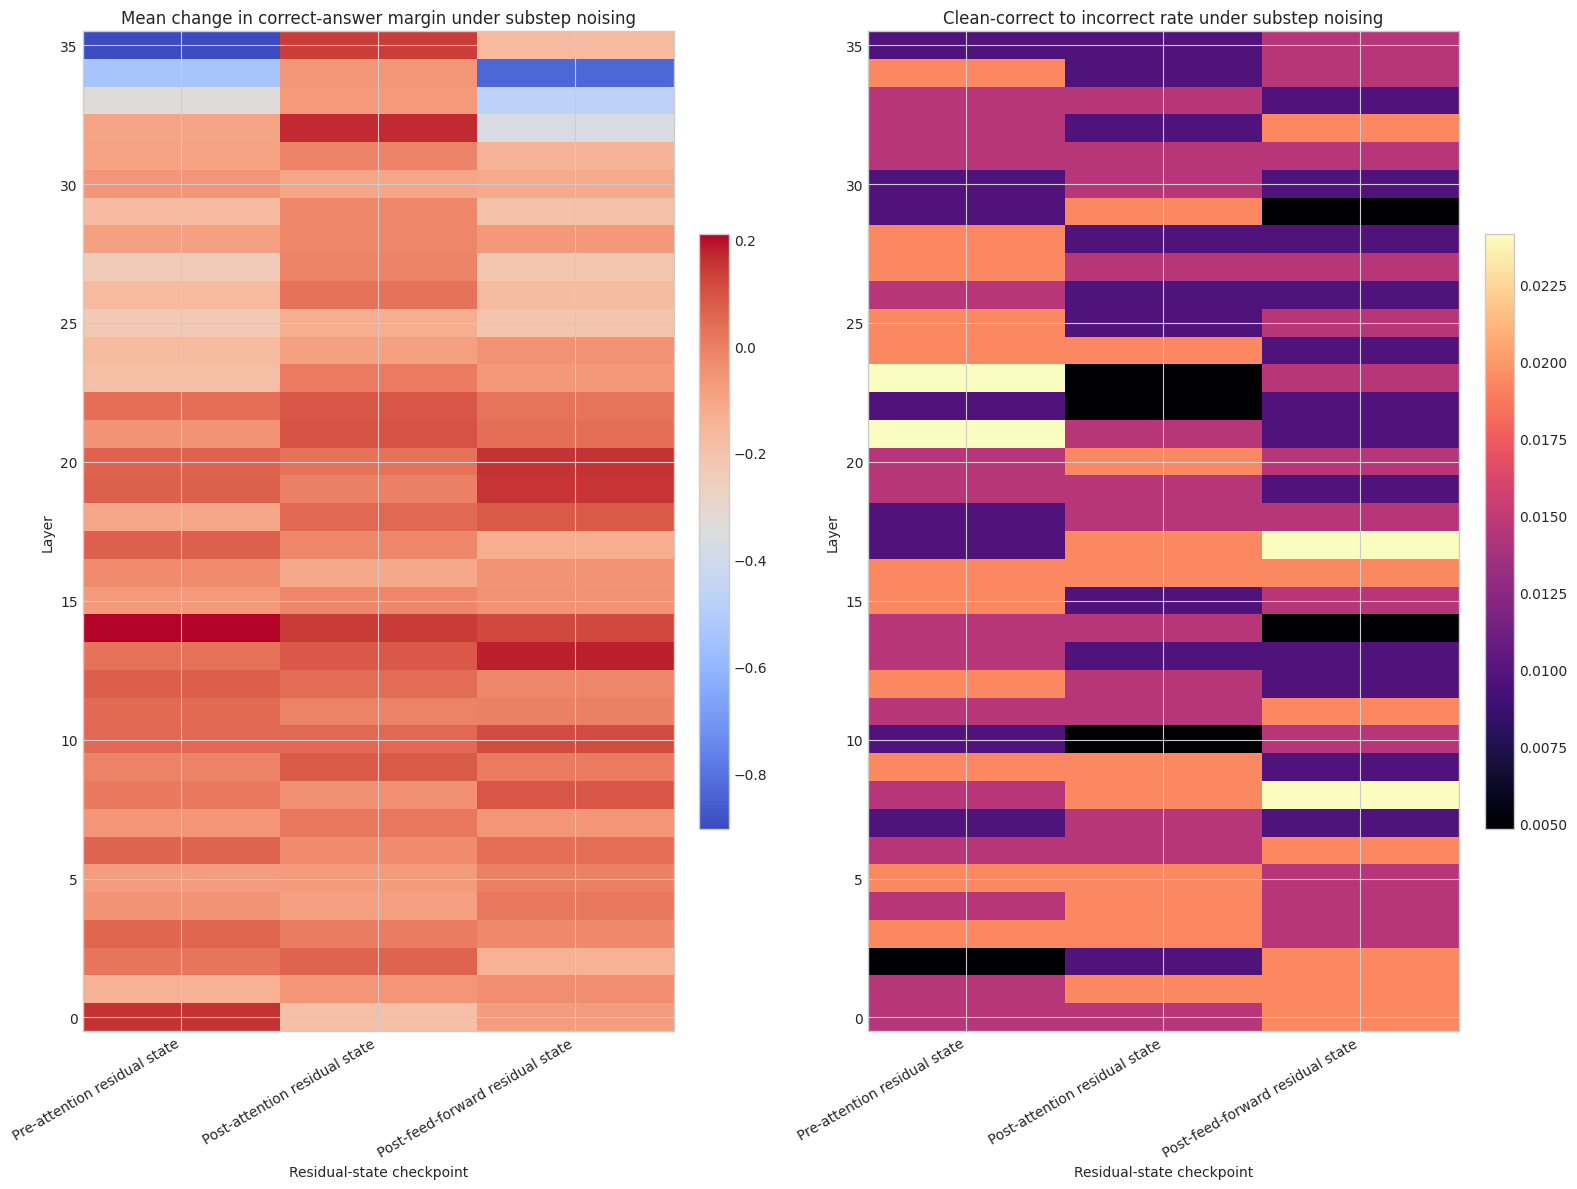

In [10]:
substep_order = ["pre_attn", "post_attn", "post_mlp"]
substep_labels = [substep_display_names[s] for s in substep_order]

def pivot_substep_metric(metric_name):
    table = (
        substep_summary.pivot(index="layer_index_1based", columns="target_substep", values=metric_name)
        .reindex(columns=substep_order)
        .sort_index()
    )
    return table


margin_delta_heat = pivot_substep_metric("mean_correct_margin_delta")
break_rate_heat = pivot_substep_metric("clean_correct_break_rate")

fig, axes = plt.subplots(1, 2, figsize=(16, 12))

im0 = axes[0].imshow(margin_delta_heat.to_numpy(), aspect="auto", origin="lower", cmap="coolwarm")
axes[0].set_title("Mean change in correct-answer margin under substep noising")
axes[0].set_xlabel("Residual-state checkpoint")
axes[0].set_ylabel("Layer")
axes[0].set_xticks(np.arange(len(substep_labels)))
axes[0].set_xticklabels(substep_labels, rotation=30, ha="right")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(break_rate_heat.to_numpy(), aspect="auto", origin="lower", cmap="magma")
axes[1].set_title("Clean-correct to incorrect rate under substep noising")
axes[1].set_xlabel("Residual-state checkpoint")
axes[1].set_ylabel("Layer")
axes[1].set_xticks(np.arange(len(substep_labels)))
axes[1].set_xticklabels(substep_labels, rotation=30, ha="right")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


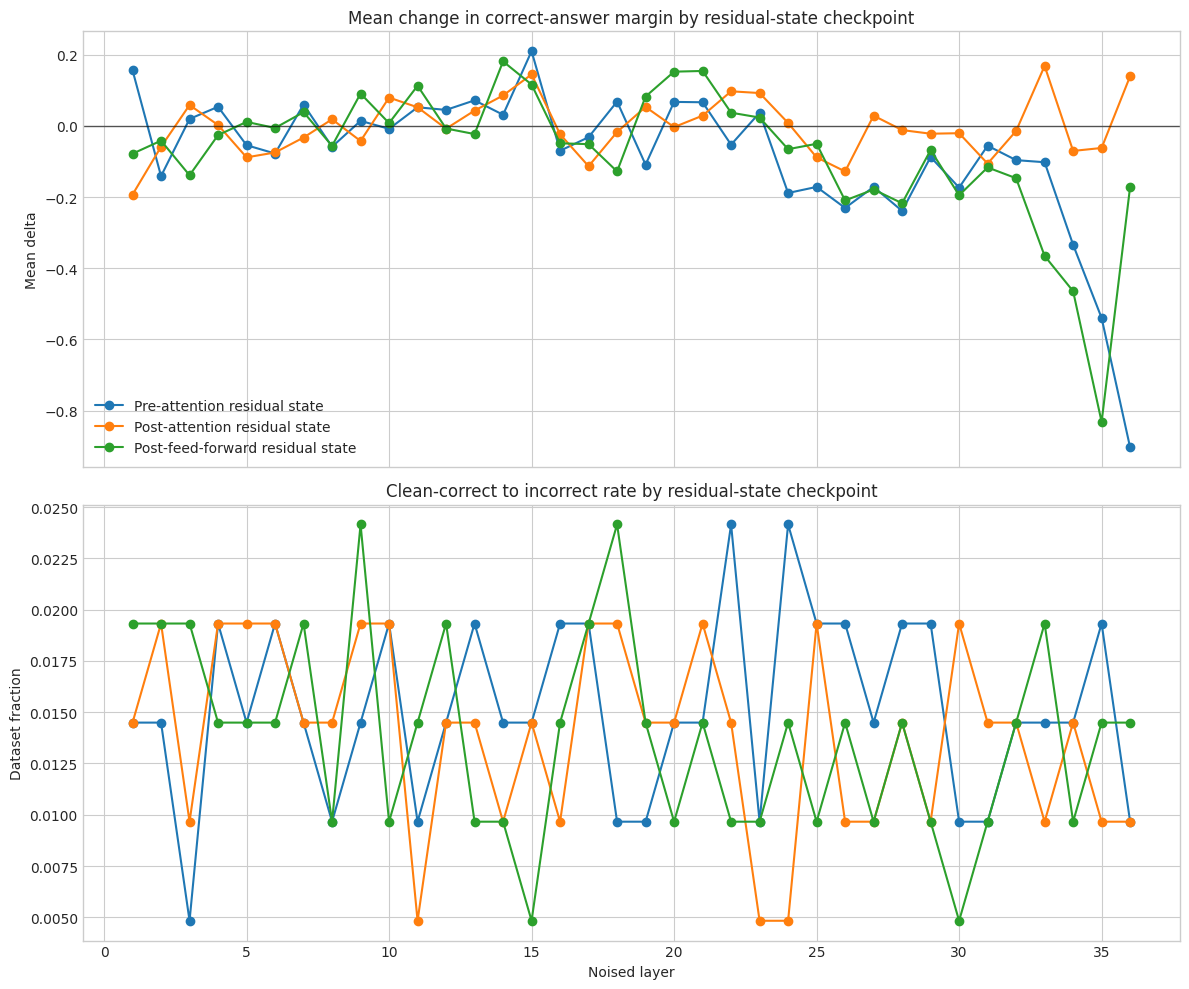

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for substep in substep_order:
    part = substep_summary.loc[substep_summary["target_substep"].eq(substep)].sort_values("layer_index_1based")
    label = substep_display_names[substep]
    axes[0].plot(part["layer_index_1based"], part["mean_correct_margin_delta"], marker="o", label=label)
    axes[1].plot(part["layer_index_1based"], part["clean_correct_break_rate"], marker="o", label=label)

axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[0].set_ylabel("Mean delta")
axes[0].set_title("Mean change in correct-answer margin by residual-state checkpoint")
axes[0].legend()

axes[1].set_xlabel("Noised layer")
axes[1].set_ylabel("Dataset fraction")
axes[1].set_title("Clean-correct to incorrect rate by residual-state checkpoint")

plt.tight_layout()
plt.show()


## Component Noising

Noise is injected into the output of one block component at a time.

- attention output
- feed-forward output


In [12]:
def run_component_noising_scan(frame, noise_scale):
    rows = []

    for target_layer in tqdm(range(L), total=L, desc="component noising"):
        for component_idx, target_component in enumerate(["attention_output", "feed_forward_output"]):
            torch.manual_seed(SEED + 10000 * (target_layer + 1) + component_idx)
            current_state = {}
            layer = decoder_layers[target_layer]

            if target_component == "attention_output":
                if not hasattr(layer, "self_attn"):
                    raise ValueError("Expected self_attn on decoder layer.")

                def hook_fn(module, args, output):
                    hidden = output[0] if isinstance(output, tuple) else output
                    hidden_out = apply_token_noise(hidden, current_state["decision_pos"], noise_scale)
                    if isinstance(output, tuple):
                        return (hidden_out,) + output[1:]
                    return hidden_out

                handle = layer.self_attn.register_forward_hook(hook_fn)

            else:
                if not hasattr(layer, "mlp"):
                    raise ValueError("Expected mlp on decoder layer.")

                def hook_fn(module, args, output):
                    hidden = output[0] if isinstance(output, tuple) else output
                    hidden_out = apply_token_noise(hidden, current_state["decision_pos"], noise_scale)
                    if isinstance(output, tuple):
                        return (hidden_out,) + output[1:]
                    return hidden_out

                handle = layer.mlp.register_forward_hook(hook_fn)

            try:
                for start in range(0, len(frame), INTERVENTION_BATCH_SIZE):
                    batch_df = frame.iloc[start:start + INTERVENTION_BATCH_SIZE].reset_index(drop=True)
                    batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
                    decision_pos = batch_cpu.pop("decision_pos")
                    batch = {k: v.to(model.device) for k, v in batch_cpu.items()}
                    decision_pos = decision_pos.to(model.device)
                    true_choice_idx = torch.tensor([LETTERS.index(str(x)) for x in batch_df["answerKey"].tolist()], dtype=torch.long, device=model.device)

                    current_state["decision_pos"] = decision_pos

                    with torch.no_grad():
                        out = model(**batch, return_dict=True, use_cache=False)

                    row_idx = torch.arange(len(batch_df), device=decision_pos.device)
                    final_logits = out.logits[row_idx, decision_pos][:, answer_ids_on_device].float()
                    pred_idx, correct_margin = compute_choice_metrics(final_logits, true_choice_idx)
                    noised_is_correct = pred_idx.eq(true_choice_idx.detach().cpu())

                    for bi in range(len(batch_df)):
                        rows.append(
                            {
                                "example_id": batch_df.loc[bi, "example_id"],
                                "target_layer": int(target_layer),
                                "target_component": target_component,
                                "noise_scale": float(noise_scale),
                                "noised_prediction_idx": int(pred_idx[bi].item()),
                                "noised_prediction": LETTERS[int(pred_idx[bi].item())],
                                "noised_correct_margin": float(correct_margin[bi].item()),
                                "noised_is_correct": bool(noised_is_correct[bi].item()),
                            }
                        )
            finally:
                handle.remove()

    return pd.DataFrame(rows)


component_df = run_component_noising_scan(eval_rows, MAIN_NOISE_SCALE)
component_df = component_df.merge(
    analysis_df[["example_id", "clean_prediction_idx", "clean_correct_margin", "clean_is_correct"]],
    on="example_id",
    how="left",
    validate="many_to_one",
)
component_df["prediction_preserved"] = component_df["noised_prediction_idx"].eq(component_df["clean_prediction_idx"])
component_df["correct_margin_delta"] = component_df["noised_correct_margin"] - component_df["clean_correct_margin"]
component_df["clean_correct_broken"] = component_df["clean_is_correct"] & (~component_df["noised_is_correct"])

component_summary = intervention_summary(component_df, ["target_layer", "target_component"])
component_summary["layer_index_1based"] = component_summary["target_layer"] + 1
component_summary["target_component_label"] = component_summary["target_component"].map(component_display_names)

display(component_summary.head(12).round(4))


component noising: 100%|██████████| 36/36 [06:10<00:00, 10.28s/it]


,target_layer,target_component,mean_correct_margin_delta,prediction_preservation_rate,noised_accuracy,clean_correct_break_rate,noised_accuracy_on_clean_correct,layer_index_1based,target_component_label
0,0,attention_output,-0.0117,0.9531,0.8086,0.0193,0.9807,1,Attention output
1,0,feed_forward_output,-0.0723,0.9766,0.7969,0.0145,0.9855,1,Feed-forward output
2,1,attention_output,-0.0200,0.9727,0.8008,0.0145,0.9855,2,Attention output
3,1,feed_forward_output,0.0361,0.9766,0.8086,0.0097,0.9903,2,Feed-forward output
4,2,attention_output,0.0669,0.9727,0.8047,0.0145,0.9855,3,Attention output
5,2,feed_forward_output,0.0195,0.9648,0.8047,0.0193,0.9807,3,Feed-forward output
6,3,attention_output,0.0059,0.9688,0.8008,0.0193,0.9807,4,Attention output
7,3,feed_forward_output,0.0464,0.9727,0.8047,0.0145,0.9855,4,Feed-forward output
8,4,attention_output,0.0444,0.9727,0.8047,0.0145,0.9855,5,Attention output
9,4,feed_forward_output,0.0747,0.9805,0.8086,0.0097,0.9903,5,Feed-forward output


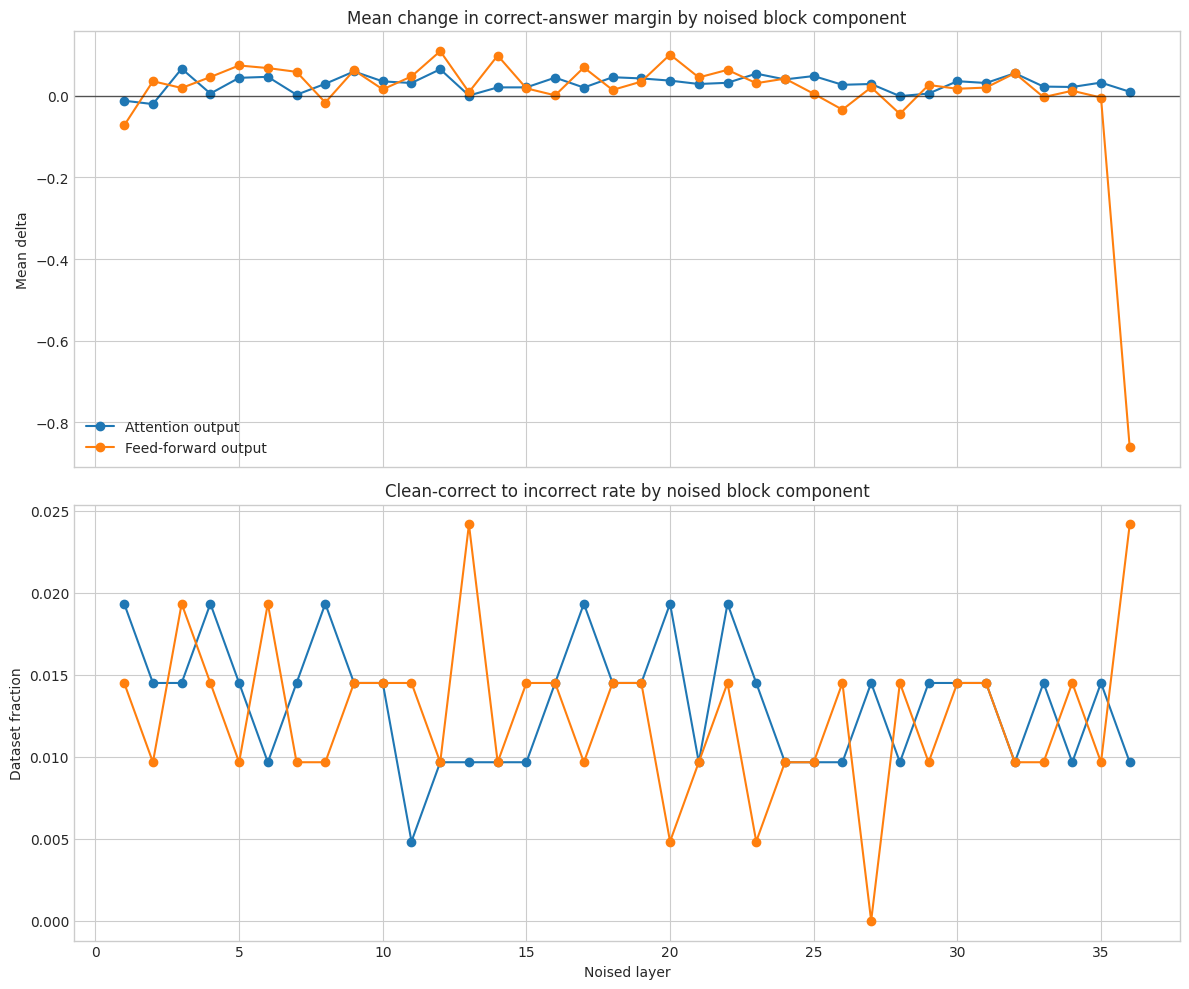

In [13]:
component_order = ["attention_output", "feed_forward_output"]

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for component in component_order:
    part = component_summary.loc[component_summary["target_component"].eq(component)].sort_values("layer_index_1based")
    label = component_display_names[component]
    axes[0].plot(part["layer_index_1based"], part["mean_correct_margin_delta"], marker="o", label=label)
    axes[1].plot(part["layer_index_1based"], part["clean_correct_break_rate"], marker="o", label=label)

axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[0].set_ylabel("Mean delta")
axes[0].set_title("Mean change in correct-answer margin by noised block component")
axes[0].legend()

axes[1].set_xlabel("Noised layer")
axes[1].set_ylabel("Dataset fraction")
axes[1].set_title("Clean-correct to incorrect rate by noised block component")

plt.tight_layout()
plt.show()


In [14]:
component_average = (
    component_summary.groupby("target_component_label")[
        ["mean_correct_margin_delta", "clean_correct_break_rate", "prediction_preservation_rate"]
    ]
    .mean()
    .reset_index()
)

display(component_average.round(4))


,target_component_label,mean_correct_margin_delta,clean_correct_break_rate,prediction_preservation_rate
0,Attention output,0.0298,0.0133,0.9718
1,Feed-forward output,0.0055,0.0125,0.9720


## Dose-Response

Repeated layer-output noising scans over multiple noise scales.


In [15]:
dose_response_parts = []

for noise_scale in DOSE_RESPONSE_SCALES:
    part = run_layer_output_noising_scan(
        eval_rows,
        noise_scale,
        f"layer-output noising scale={noise_scale}",
    )
    part["noise_scale"] = float(noise_scale)
    dose_response_parts.append(part)

dose_response_df = pd.concat(dose_response_parts, ignore_index=True)
dose_response_df = dose_response_df.merge(
    analysis_df[["example_id", "clean_prediction_idx", "clean_correct_margin", "clean_is_correct"]],
    on="example_id",
    how="left",
    validate="many_to_one",
)
dose_response_df["prediction_preserved"] = dose_response_df["noised_prediction_idx"].eq(dose_response_df["clean_prediction_idx"])
dose_response_df["correct_margin_delta"] = dose_response_df["noised_correct_margin"] - dose_response_df["clean_correct_margin"]
dose_response_df["clean_correct_broken"] = dose_response_df["clean_is_correct"] & (~dose_response_df["noised_is_correct"])

dose_response_summary = intervention_summary(dose_response_df, ["noise_scale", "target_layer"])
dose_response_summary["layer_index_1based"] = dose_response_summary["target_layer"] + 1

display(dose_response_summary.head(12).round(4))


layer-output noising scale=0.5: 100%|██████████| 36/36 [03:04<00:00,  5.14s/it]


,noise_scale,target_layer,mean_correct_margin_delta,prediction_preservation_rate,noised_accuracy,clean_correct_break_rate,noised_accuracy_on_clean_correct,layer_index_1based
0,0.05,0,0.0317,0.9648,0.8047,0.0145,0.9855,1
1,0.05,1,0.0190,0.9727,0.8086,0.0097,0.9903,2
2,0.05,2,0.0610,0.9688,0.8047,0.0097,0.9903,3
3,0.05,3,0.0610,0.9805,0.8047,0.0097,0.9903,4
4,0.05,4,0.0718,0.9688,0.8008,0.0193,0.9807,5
5,0.05,5,0.0522,0.9766,0.8086,0.0097,0.9903,6
6,0.05,6,0.0527,0.9648,0.8008,0.0193,0.9807,7
7,0.05,7,0.0386,0.9688,0.8008,0.0193,0.9807,8
8,0.05,8,0.0430,0.9727,0.8086,0.0097,0.9903,9
9,0.05,9,0.0586,0.9688,0.8047,0.0145,0.9855,10


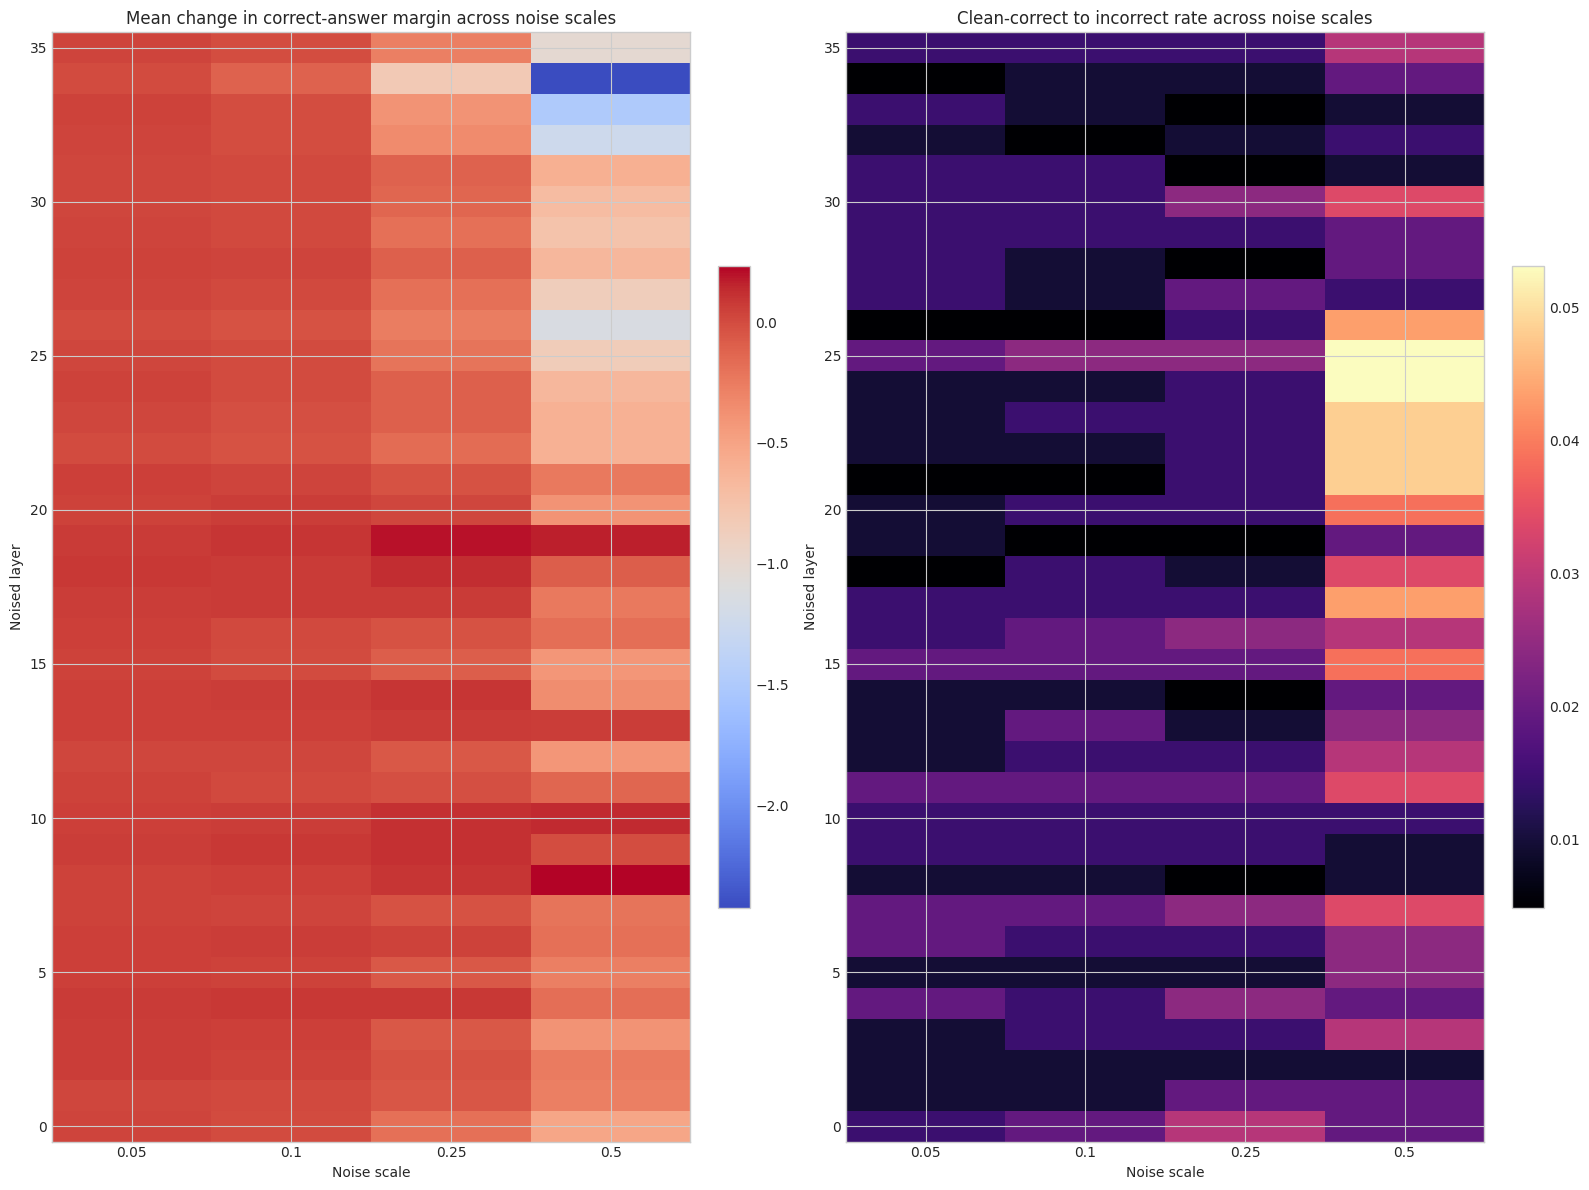

In [16]:
def pivot_dose_metric(metric_name):
    table = (
        dose_response_summary.pivot(index="layer_index_1based", columns="noise_scale", values=metric_name)
        .sort_index()
    )
    return table


dose_margin_delta = pivot_dose_metric("mean_correct_margin_delta")
dose_break_rate = pivot_dose_metric("clean_correct_break_rate")

fig, axes = plt.subplots(1, 2, figsize=(16, 12))

im0 = axes[0].imshow(dose_margin_delta.to_numpy(), aspect="auto", origin="lower", cmap="coolwarm")
axes[0].set_title("Mean change in correct-answer margin across noise scales")
axes[0].set_xlabel("Noise scale")
axes[0].set_ylabel("Noised layer")
axes[0].set_xticks(np.arange(len(dose_margin_delta.columns)))
axes[0].set_xticklabels([str(x) for x in dose_margin_delta.columns])
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(dose_break_rate.to_numpy(), aspect="auto", origin="lower", cmap="magma")
axes[1].set_title("Clean-correct to incorrect rate across noise scales")
axes[1].set_xlabel("Noise scale")
axes[1].set_ylabel("Noised layer")
axes[1].set_xticks(np.arange(len(dose_break_rate.columns)))
axes[1].set_xticklabels([str(x) for x in dose_break_rate.columns])
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


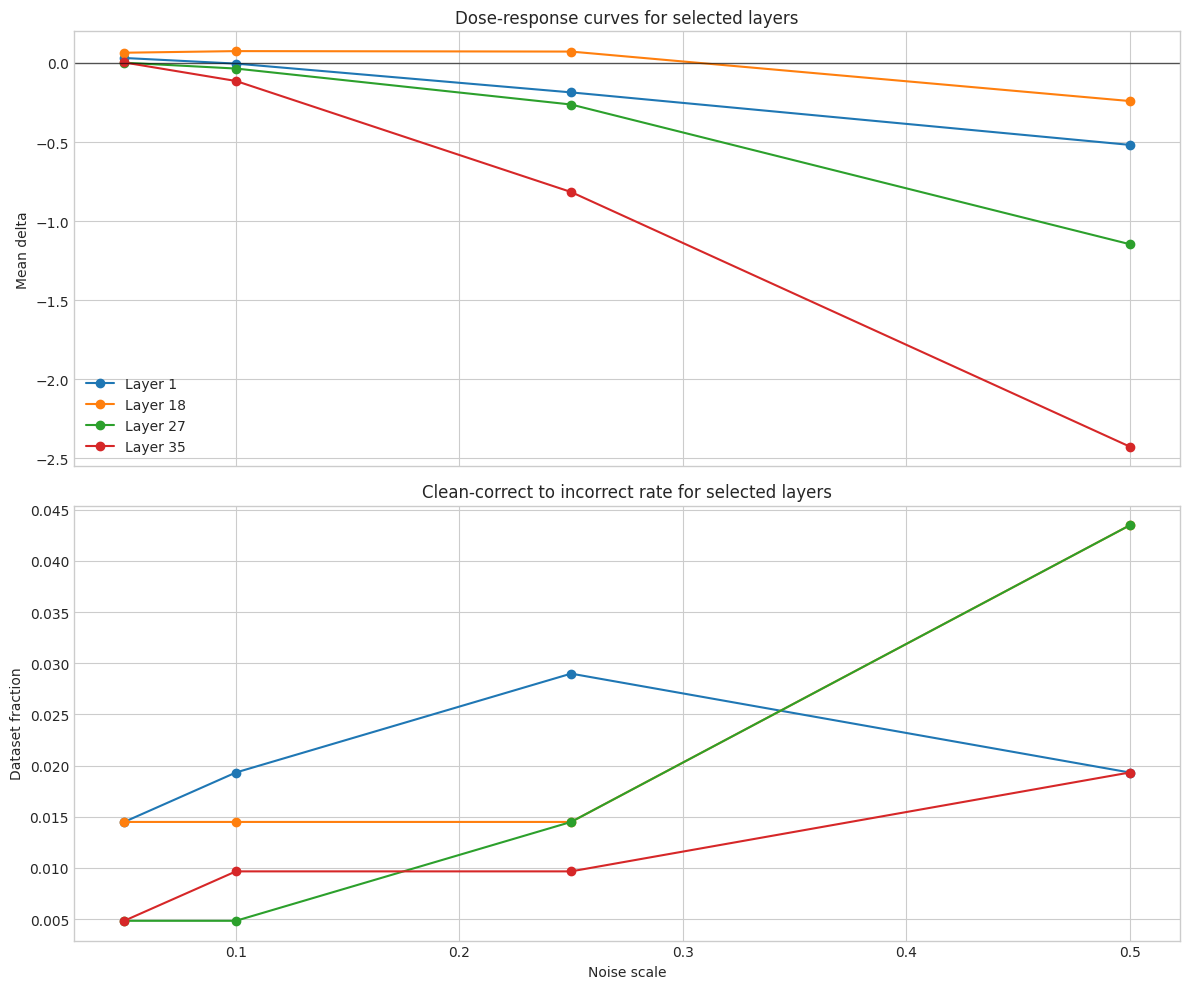

In [31]:
selected_layers = sorted({1, max(1, L // 2), 27, L-1})
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for layer_index_1based in selected_layers:
    part = dose_response_summary.loc[dose_response_summary["layer_index_1based"].eq(layer_index_1based)].sort_values("noise_scale")
    axes[0].plot(part["noise_scale"], part["mean_correct_margin_delta"], marker="o", label=f"Layer {layer_index_1based}")
    axes[1].plot(part["noise_scale"], part["clean_correct_break_rate"], marker="o", label=f"Layer {layer_index_1based}")

axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[0].set_ylabel("Mean delta")
axes[0].set_title("Dose-response curves for selected layers")
axes[0].legend()

axes[1].set_xlabel("Noise scale")
axes[1].set_ylabel("Dataset fraction")
axes[1].set_title("Clean-correct to incorrect rate for selected layers")

plt.tight_layout()
plt.show()


## Hypothesis-Driven Follow-Up

Targeted analysis of intervention outputs against descriptive layerwise signals.


### Descriptive Reference Curves

Clean layer-output reference curves:

- normalized answer-choice entropy
- answer-choice top1-top2 logit gap


In [18]:
def extract_descriptive_reference_curves(frame):
    rows = []

    for start in tqdm(range(0, len(frame), CLEAN_BATCH_SIZE), total=int(math.ceil(len(frame) / CLEAN_BATCH_SIZE)), desc="descriptive reference curves"):
        batch_df = frame.iloc[start:start + CLEAN_BATCH_SIZE].reset_index(drop=True)
        batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
        decision_pos = batch_cpu.pop("decision_pos")
        batch = {k: v.to(model.device) for k, v in batch_cpu.items()}
        decision_pos = decision_pos.to(model.device)

        with torch.no_grad():
            out = model(**batch, output_hidden_states=True, return_dict=True, use_cache=False)

        hidden_states = out.hidden_states
        bsz = len(batch_df)
        row_idx = torch.arange(bsz, device=decision_pos.device)

        entropy_blocks = []
        gap_blocks = []

        for li in range(L):
            hidden = hidden_states[li + 1][row_idx, decision_pos].float()
            readout = maybe_apply_final_norm_gpu(hidden, li)
            choice_logits = torch.matmul(readout, model.lm_head.weight[answer_ids_on_device].float().T)
            choice_probs = torch.softmax(choice_logits, dim=-1)
            choice_entropy = -(choice_probs * torch.log(torch.clamp(choice_probs, min=1e-12))).sum(dim=-1) / log_answer_choice_count
            sorted_logits = torch.sort(choice_logits, dim=-1, descending=True).values
            top1_top2_gap = sorted_logits[:, 0] - sorted_logits[:, 1]

            entropy_blocks.append(choice_entropy.detach().cpu().numpy().astype(np.float32))
            gap_blocks.append(top1_top2_gap.detach().cpu().numpy().astype(np.float32))

        entropy_matrix = np.stack(entropy_blocks, axis=1)
        gap_matrix = np.stack(gap_blocks, axis=1)

        for bi in range(bsz):
            rows.append(
                {
                    "example_id": batch_df.loc[bi, "example_id"],
                    "answer_choice_entropy_curve": entropy_matrix[bi].copy(),
                    "answer_choice_top1_top2_gap_curve": gap_matrix[bi].copy(),
                }
            )

    return pd.DataFrame(rows)


descriptive_df = extract_descriptive_reference_curves(eval_rows)
analysis_df = analysis_df.merge(descriptive_df, on="example_id", how="left", validate="one_to_one")

reference_entropy_curve = np.stack(analysis_df["answer_choice_entropy_curve"].to_list(), axis=0).mean(axis=0)
reference_gap_curve = np.stack(analysis_df["answer_choice_top1_top2_gap_curve"].to_list(), axis=0).mean(axis=0)

descriptive_layer_summary = pd.DataFrame(
    {
        "layer_index_1based": np.arange(1, L + 1),
        "mean_answer_choice_entropy": reference_entropy_curve,
        "mean_answer_choice_top1_top2_gap": reference_gap_curve,
    }
)

display(descriptive_layer_summary.head(10).round(4))


descriptive reference curves: 100%|██████████| 64/64 [00:03<00:00, 16.25it/s]


,layer_index_1based,mean_answer_choice_entropy,mean_answer_choice_top1_top2_gap
0,1,0.6424,0.6486
1,2,0.7592,0.1269
2,3,0.7520,0.2063
3,4,0.4984,1.5393
4,5,0.2442,3.1510
5,6,0.6647,1.1455
6,7,0.5182,1.0993
7,8,0.5764,0.8832
8,9,0.6148,0.5232
9,10,0.8724,0.5939


### Early-Middle-Late Aggregation


In [19]:
region_edges = np.linspace(0, L, 4, dtype=int)

def assign_layer_region(layer_index_1based):
    if layer_index_1based <= region_edges[1]:
        return "Early layers"
    if layer_index_1based <= region_edges[2]:
        return "Middle layers"
    return "Late layers"


layer_output_df["layer_region"] = layer_output_df["target_layer"].add(1).map(assign_layer_region)
region_summary = intervention_summary(layer_output_df, ["layer_region"])
region_summary["layer_region"] = pd.Categorical(
    region_summary["layer_region"],
    categories=["Early layers", "Middle layers", "Late layers"],
    ordered=True,
)
region_summary = region_summary.sort_values("layer_region").reset_index(drop=True)

display(region_summary.round(4))


,layer_region,mean_correct_margin_delta,prediction_preservation_rate,noised_accuracy,clean_correct_break_rate,noised_accuracy_on_clean_correct
0,Early layers,0.0003,0.9635,0.8070,0.0165,0.9835
1,Middle layers,0.0078,0.9639,0.8105,0.0133,0.9867
2,Late layers,-0.2602,0.9688,0.8092,0.0133,0.9867


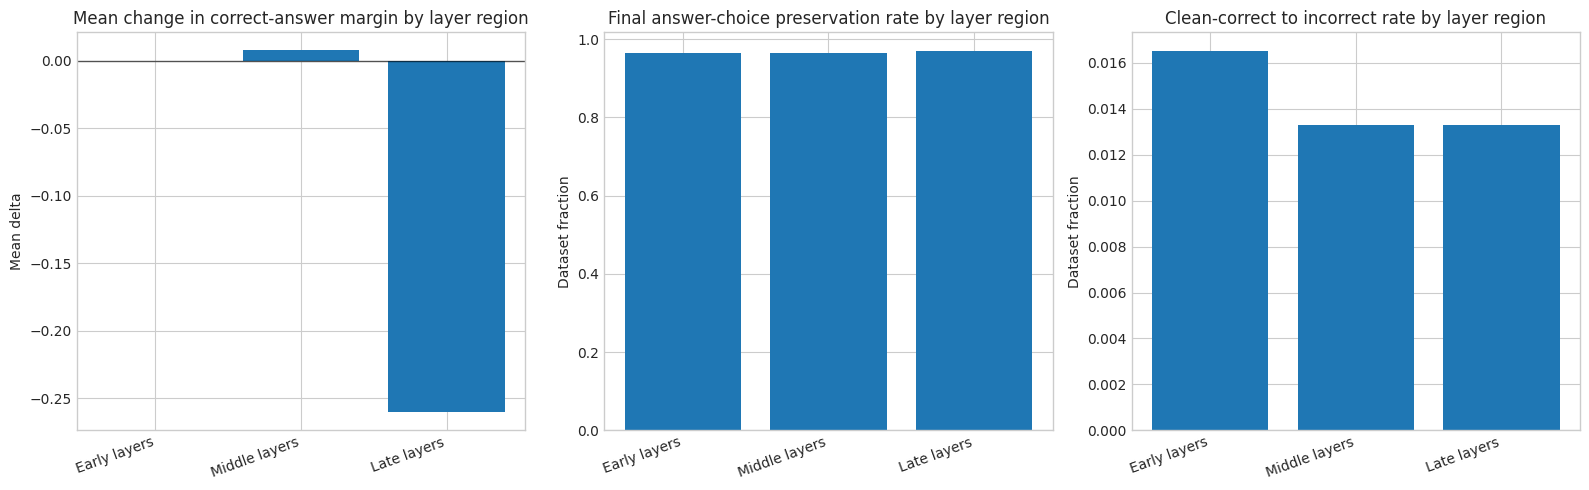

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(len(region_summary))
labels = region_summary["layer_region"].astype(str).tolist()

axes[0].bar(x, region_summary["mean_correct_margin_delta"])
axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=20, ha="right")
axes[0].set_ylabel("Mean delta")
axes[0].set_title("Mean change in correct-answer margin by layer region")

axes[1].bar(x, region_summary["prediction_preservation_rate"])
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=20, ha="right")
axes[1].set_ylabel("Dataset fraction")
axes[1].set_title("Final answer-choice preservation rate by layer region")

axes[2].bar(x, region_summary["clean_correct_break_rate"])
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=20, ha="right")
axes[2].set_ylabel("Dataset fraction")
axes[2].set_title("Clean-correct to incorrect rate by layer region")

plt.tight_layout()
plt.show()


### Stabilization-Window Comparison


In [21]:
window_size = 4
stabilization_start = min(max(1, 25), max(1, L - window_size + 1))
stabilization_layers = set(range(stabilization_start, min(L, stabilization_start + window_size - 1) + 1))

middle_start = max(1, (L // 2) - (window_size // 2) + 1)
middle_start = min(middle_start, max(1, L - window_size + 1))
middle_layers = set(range(middle_start, min(L, middle_start + window_size - 1) + 1))

early_layers = set(range(1, min(L, window_size) + 1))
late_start = max(1, L - window_size + 1)
late_layers = set(range(late_start, L + 1))

def assign_window_label(layer_index_1based):
    if layer_index_1based in stabilization_layers:
        return "Stabilization window"
    if layer_index_1based in early_layers:
        return "Early control window"
    if layer_index_1based in middle_layers:
        return "Middle control window"
    if layer_index_1based in late_layers:
        return "Late control window"
    return None


window_df = layer_output_df.copy()
window_df["window_label"] = window_df["target_layer"].add(1).map(assign_window_label)
window_df = window_df.loc[window_df["window_label"].notna()].copy()

window_summary = intervention_summary(window_df, ["window_label"])
window_summary["window_label"] = pd.Categorical(
    window_summary["window_label"],
    categories=[
        "Early control window",
        "Middle control window",
        "Stabilization window",
        "Late control window",
    ],
    ordered=True,
)
window_summary = window_summary.sort_values("window_label").reset_index(drop=True)

display(window_summary.round(4))


,window_label,mean_correct_margin_delta,prediction_preservation_rate,noised_accuracy,clean_correct_break_rate,noised_accuracy_on_clean_correct
0,Early control window,-0.0829,0.9580,0.8086,0.0181,0.9819
1,Middle control window,0.0928,0.9639,0.8096,0.0133,0.9867
2,Stabilization window,-0.1892,0.9580,0.8086,0.0181,0.9819
3,Late control window,-0.4550,0.9775,0.8086,0.0097,0.9903


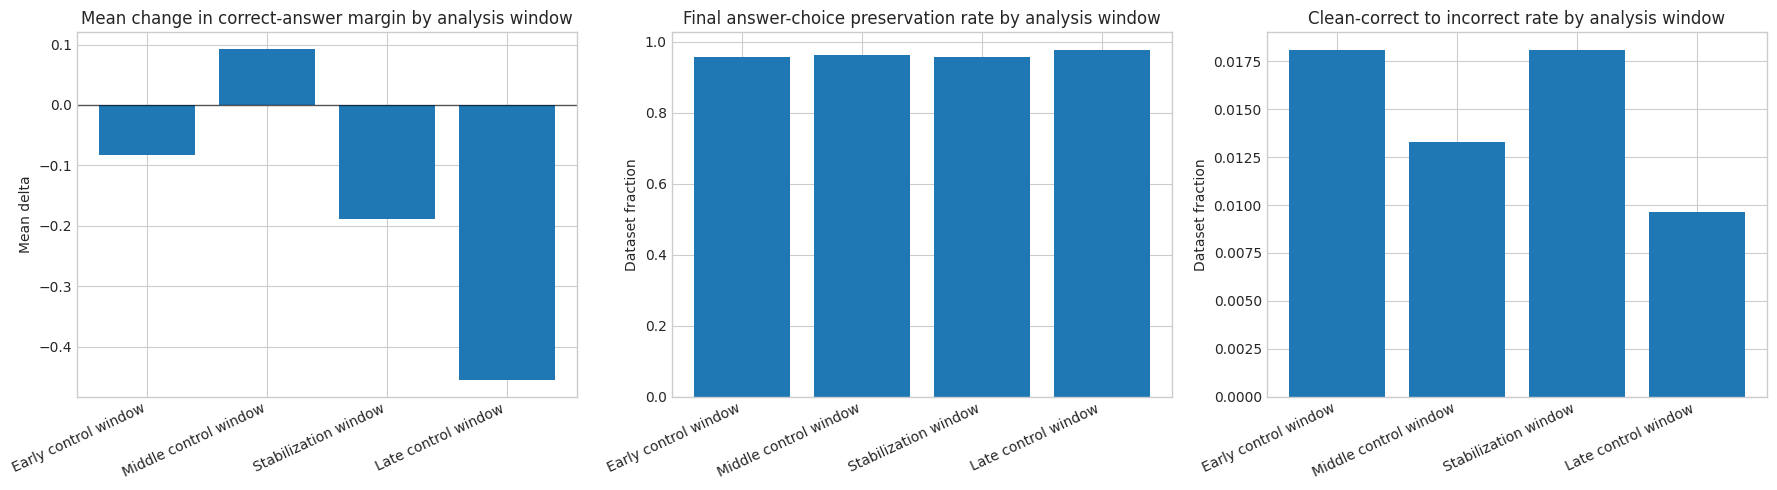

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(window_summary))
labels = window_summary["window_label"].astype(str).tolist()

axes[0].bar(x, window_summary["mean_correct_margin_delta"])
axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=25, ha="right")
axes[0].set_ylabel("Mean delta")
axes[0].set_title("Mean change in correct-answer margin by analysis window")

axes[1].bar(x, window_summary["prediction_preservation_rate"])
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=25, ha="right")
axes[1].set_ylabel("Dataset fraction")
axes[1].set_title("Final answer-choice preservation rate by analysis window")

axes[2].bar(x, window_summary["clean_correct_break_rate"])
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=25, ha="right")
axes[2].set_ylabel("Dataset fraction")
axes[2].set_title("Clean-correct to incorrect rate by analysis window")

plt.tight_layout()
plt.show()


### Descriptive-Versus-Causal Comparison For Entropy


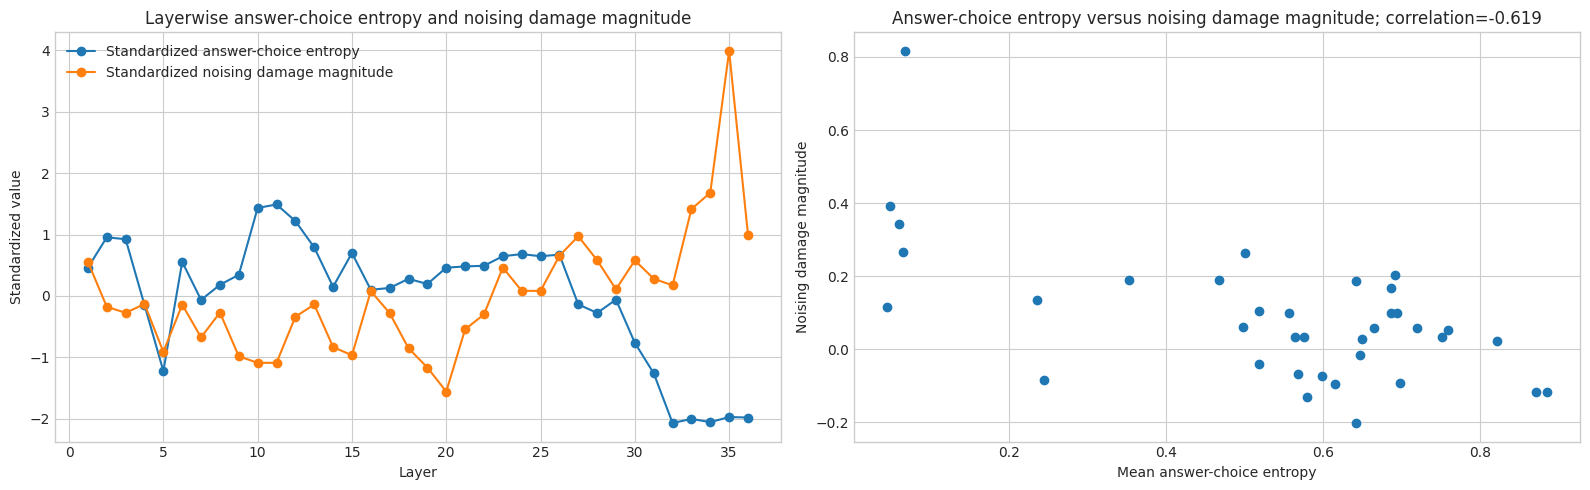

,metric_pair,correlation
0,Answer-choice entropy vs noising damage magnitude,-0.6194
1,Answer-choice entropy vs clean-correct break rate,0.1658


In [23]:
comparison_df = layer_output_summary.merge(descriptive_layer_summary, on="layer_index_1based", how="inner", validate="one_to_one")
comparison_df["damage_magnitude"] = -comparison_df["mean_correct_margin_delta"]

entropy_overlay_damage = standardize_series(comparison_df["damage_magnitude"])
entropy_overlay_curve = standardize_series(comparison_df["mean_answer_choice_entropy"])
entropy_damage_corr = float(np.corrcoef(comparison_df["mean_answer_choice_entropy"], comparison_df["damage_magnitude"])[0, 1])
entropy_break_corr = float(np.corrcoef(comparison_df["mean_answer_choice_entropy"], comparison_df["clean_correct_break_rate"])[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(comparison_df["layer_index_1based"], entropy_overlay_curve, marker="o", label="Standardized answer-choice entropy")
axes[0].plot(comparison_df["layer_index_1based"], entropy_overlay_damage, marker="o", label="Standardized noising damage magnitude")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Standardized value")
axes[0].set_title("Layerwise answer-choice entropy and noising damage magnitude")
axes[0].legend()

axes[1].scatter(comparison_df["mean_answer_choice_entropy"], comparison_df["damage_magnitude"])
axes[1].set_xlabel("Mean answer-choice entropy")
axes[1].set_ylabel("Noising damage magnitude")
axes[1].set_title(f"Answer-choice entropy versus noising damage magnitude; correlation={entropy_damage_corr:.3f}")

plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        {
            "metric_pair": [
                "Answer-choice entropy vs noising damage magnitude",
                "Answer-choice entropy vs clean-correct break rate",
            ],
            "correlation": [
                entropy_damage_corr,
                entropy_break_corr,
            ],
        }
    ).round(4)
)


### Descriptive-Versus-Causal Comparison For Logit Gap


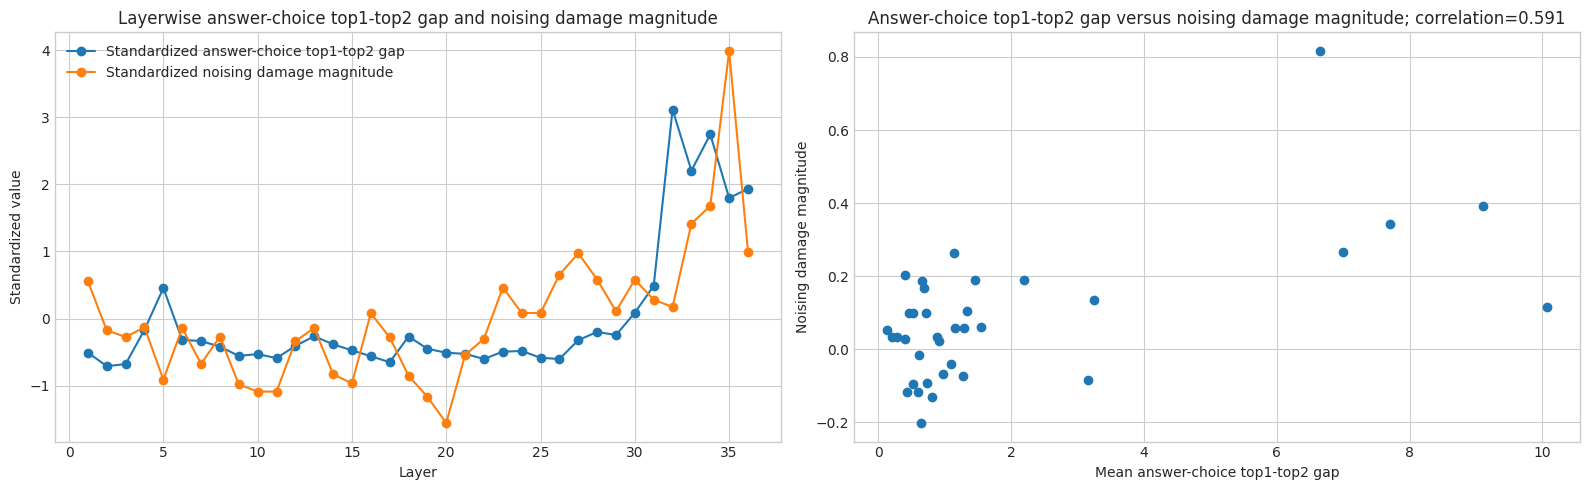

,metric_pair,correlation
0,Answer-choice top1-top2 gap vs noising damage ...,0.5909
1,Answer-choice top1-top2 gap vs clean-correct b...,-0.3189


In [24]:
gap_overlay_damage = standardize_series(comparison_df["damage_magnitude"])
gap_overlay_curve = standardize_series(comparison_df["mean_answer_choice_top1_top2_gap"])
gap_damage_corr = float(np.corrcoef(comparison_df["mean_answer_choice_top1_top2_gap"], comparison_df["damage_magnitude"])[0, 1])
gap_break_corr = float(np.corrcoef(comparison_df["mean_answer_choice_top1_top2_gap"], comparison_df["clean_correct_break_rate"])[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(comparison_df["layer_index_1based"], gap_overlay_curve, marker="o", label="Standardized answer-choice top1-top2 gap")
axes[0].plot(comparison_df["layer_index_1based"], gap_overlay_damage, marker="o", label="Standardized noising damage magnitude")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Standardized value")
axes[0].set_title("Layerwise answer-choice top1-top2 gap and noising damage magnitude")
axes[0].legend()

axes[1].scatter(comparison_df["mean_answer_choice_top1_top2_gap"], comparison_df["damage_magnitude"])
axes[1].set_xlabel("Mean answer-choice top1-top2 gap")
axes[1].set_ylabel("Noising damage magnitude")
axes[1].set_title(f"Answer-choice top1-top2 gap versus noising damage magnitude; correlation={gap_damage_corr:.3f}")

plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        {
            "metric_pair": [
                "Answer-choice top1-top2 gap vs noising damage magnitude",
                "Answer-choice top1-top2 gap vs clean-correct break rate",
            ],
            "correlation": [
                gap_damage_corr,
                gap_break_corr,
            ],
        }
    ).round(4)
)


### Seed Robustness For Selected Layer-Output Scans


In [25]:
def run_selected_layer_output_noising_scan(frame, noise_scale, target_layers, seeds):
    rows = []

    for scan_seed in tqdm(seeds, total=len(seeds), desc="seed robustness"):
        for target_layer in target_layers:
            torch.manual_seed(int(scan_seed) + int(target_layer))
            current_state = {}

            def noise_hook(module, args, output):
                hidden = output[0] if isinstance(output, tuple) else output
                hidden_out = apply_token_noise(hidden, current_state["decision_pos"], noise_scale)
                if isinstance(output, tuple):
                    return (hidden_out,) + output[1:]
                return hidden_out

            handle = decoder_layers[target_layer].register_forward_hook(noise_hook)

            try:
                for start in range(0, len(frame), INTERVENTION_BATCH_SIZE):
                    batch_df = frame.iloc[start:start + INTERVENTION_BATCH_SIZE].reset_index(drop=True)
                    batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
                    decision_pos = batch_cpu.pop("decision_pos")
                    batch = {k: v.to(model.device) for k, v in batch_cpu.items()}
                    decision_pos = decision_pos.to(model.device)
                    true_choice_idx = torch.tensor([LETTERS.index(str(x)) for x in batch_df["answerKey"].tolist()], dtype=torch.long, device=model.device)

                    current_state["decision_pos"] = decision_pos

                    with torch.no_grad():
                        out = model(**batch, return_dict=True, use_cache=False)

                    row_idx = torch.arange(len(batch_df), device=decision_pos.device)
                    final_logits = out.logits[row_idx, decision_pos][:, answer_ids_on_device].float()
                    pred_idx, correct_margin = compute_choice_metrics(final_logits, true_choice_idx)
                    noised_is_correct = pred_idx.eq(true_choice_idx.detach().cpu())

                    for bi in range(len(batch_df)):
                        rows.append(
                            {
                                "example_id": batch_df.loc[bi, "example_id"],
                                "scan_seed": int(scan_seed),
                                "target_layer": int(target_layer),
                                "noised_prediction_idx": int(pred_idx[bi].item()),
                                "noised_correct_margin": float(correct_margin[bi].item()),
                                "noised_is_correct": bool(noised_is_correct[bi].item()),
                            }
                        )
            finally:
                handle.remove()

    return pd.DataFrame(rows)


most_damaging_layer_0based = int(layer_output_summary.sort_values("clean_correct_break_rate", ascending=False)["target_layer"].iloc[0])
selected_layers_for_seed_scan = sorted(set([0, L // 2, L - 1, most_damaging_layer_0based]))

seed_df = run_selected_layer_output_noising_scan(
    eval_rows,
    MAIN_NOISE_SCALE,
    selected_layers_for_seed_scan,
    SEED_ROBUSTNESS_SEEDS,
)
seed_df = seed_df.merge(
    analysis_df[["example_id", "clean_prediction_idx", "clean_correct_margin", "clean_is_correct"]],
    on="example_id",
    how="left",
    validate="many_to_one",
)
seed_df["prediction_preserved"] = seed_df["noised_prediction_idx"].eq(seed_df["clean_prediction_idx"])
seed_df["correct_margin_delta"] = seed_df["noised_correct_margin"] - seed_df["clean_correct_margin"]
seed_df["clean_correct_broken"] = seed_df["clean_is_correct"] & (~seed_df["noised_is_correct"])

seed_summary = (
    intervention_summary(seed_df, ["scan_seed", "target_layer"])
    .assign(layer_index_1based=lambda df: df["target_layer"] + 1)
)

seed_summary_agg = (
    seed_summary.groupby("layer_index_1based")[
        ["mean_correct_margin_delta", "prediction_preservation_rate", "clean_correct_break_rate"]
    ]
    .agg(["mean", "std"])
)

display(seed_summary_agg.round(4))


seed robustness: 100%|██████████| 4/4 [01:02<00:00, 15.54s/it]


mean_correct_margin_delta         prediction_preservation_rate         clean_correct_break_rate        
                                        mean     std                         mean     std                     mean     std
layer_index_1based                                                                                                        
1                                    -0.0844  0.0774                       0.9590  0.0093                   0.0181  0.0083
19                                    0.0806  0.0848                       0.9717  0.0067                   0.0133  0.0072
36                                   -0.2472  0.0320                       0.9688  0.0055                   0.0145  0.0079

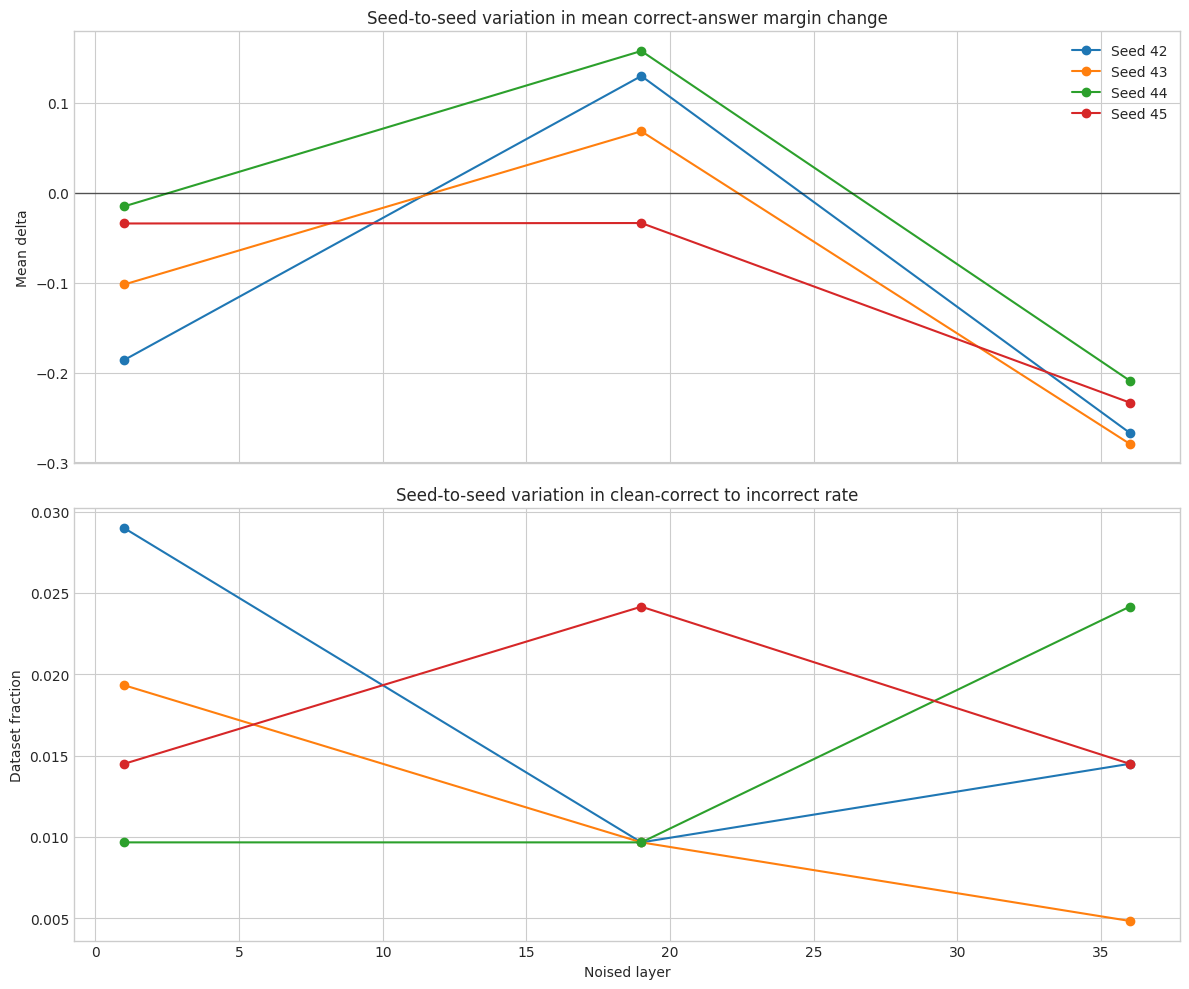

In [26]:
seed_plot_df = (
    seed_summary.groupby(["scan_seed", "layer_index_1based"])[
        ["mean_correct_margin_delta", "clean_correct_break_rate"]
    ]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for scan_seed in sorted(seed_plot_df["scan_seed"].unique()):
    part = seed_plot_df.loc[seed_plot_df["scan_seed"].eq(scan_seed)].sort_values("layer_index_1based")
    axes[0].plot(part["layer_index_1based"], part["mean_correct_margin_delta"], marker="o", label=f"Seed {scan_seed}")
    axes[1].plot(part["layer_index_1based"], part["clean_correct_break_rate"], marker="o", label=f"Seed {scan_seed}")

axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[0].set_ylabel("Mean delta")
axes[0].set_title("Seed-to-seed variation in mean correct-answer margin change")
axes[0].legend()

axes[1].set_xlabel("Noised layer")
axes[1].set_ylabel("Dataset fraction")
axes[1].set_title("Seed-to-seed variation in clean-correct to incorrect rate")

plt.tight_layout()
plt.show()
